In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

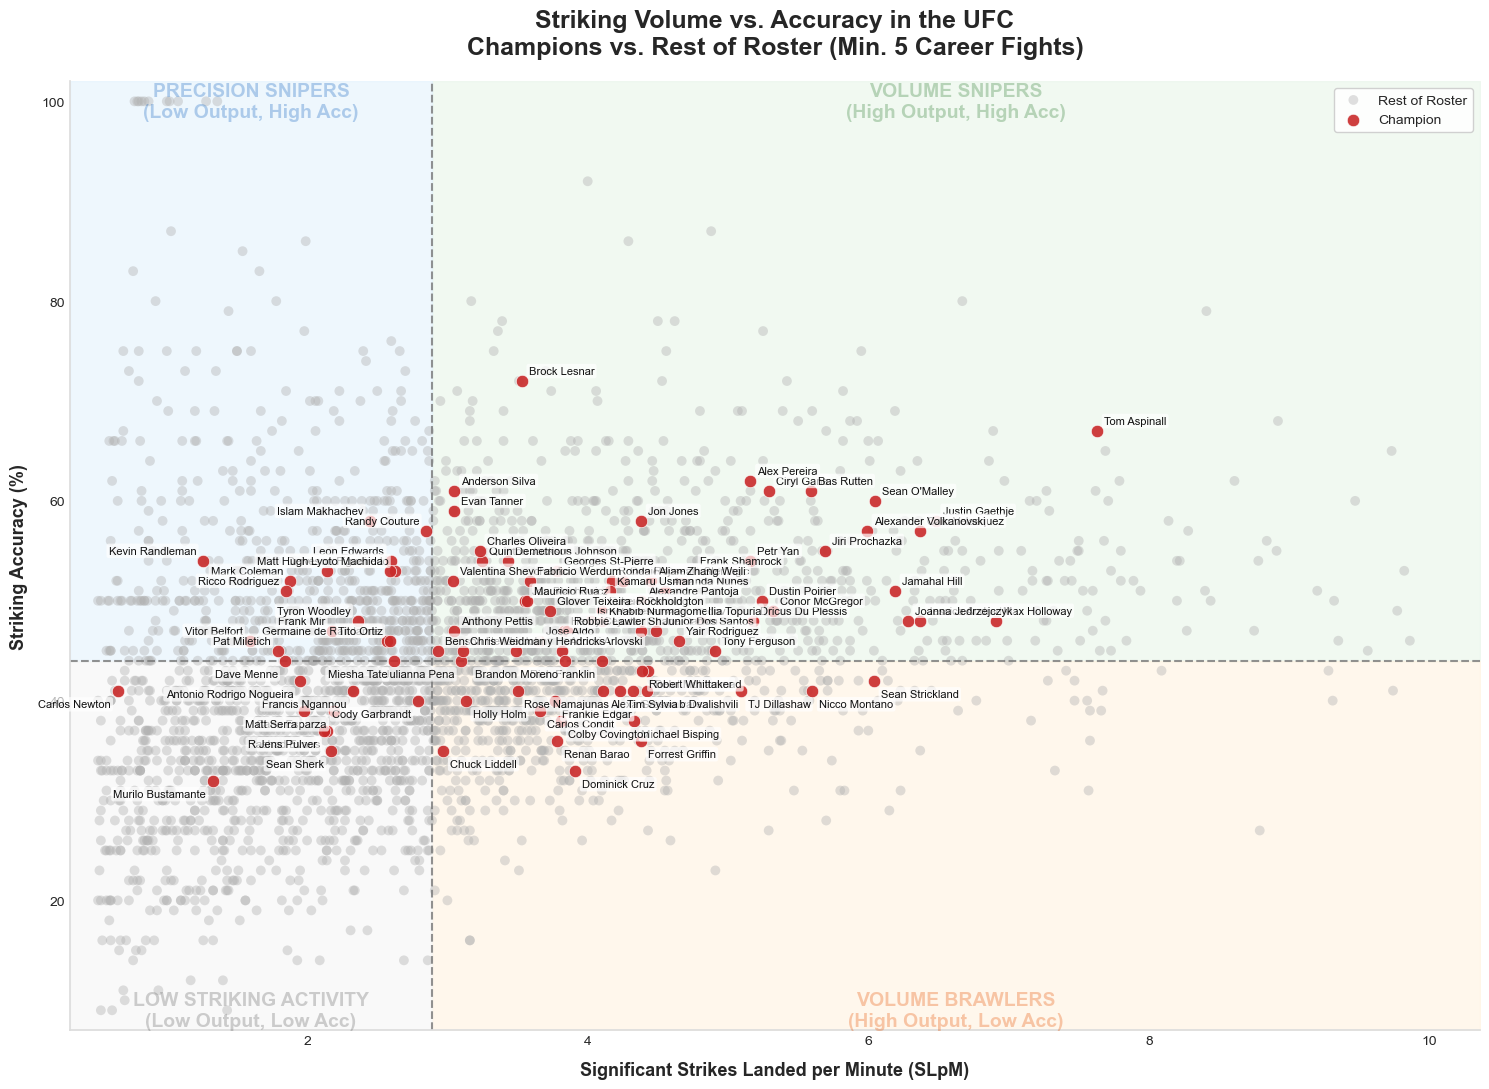

In [8]:
df = pd.read_csv('ufc_fighters_final.csv')

df['Str_Acc'] = df['Str_Acc'].astype(str).str.rstrip('%').astype(float)
df['SLpM'] = df['SLpM'].astype(float)

df['Total_Fights'] = df['Wins'] + df['Losses'] + df['Draws']

df_filtered = df[(df['Total_Fights'] >= 5) & (df['SLpM'] > 0.5) & (df['SLpM'] < 10)].copy()

champions_list = [
    # Heavyweight
    "Mark Coleman", "Maurice Smith", "Randy Couture", "Bas Rutten", "Kevin Randleman", 
    "Ricco Rodriguez", "Tim Sylvia", "Andrei Arlovski", "Frank Mir", "Brock Lesnar", 
    "Cain Velasquez", "Junior Dos Santos", "Fabricio Werdum", "Stipe Miocic", "Daniel Cormier", 
    "Francis Ngannou", "Jon Jones", "Tom Aspinall", "Ciryl Gane", "Shane Carwin", "Antonio Rodrigo Nogueira",
    # Light Heavyweight
    "Frank Shamrock", "Tito Ortiz", "Vitor Belfort", "Chuck Liddell", "Quinton Jackson", 
    "Forrest Griffin", "Rashad Evans", "Lyoto Machida", "Mauricio Rua", "Jan Blachowicz", 
    "Glover Teixeira", "Jiri Prochazka", "Jamahal Hill", "Alex Pereira",
    # Middleweight
    "Dave Menne", "Murilo Bustamante", "Evan Tanner", "Rich Franklin", "Anderson Silva", 
    "Chris Weidman", "Luke Rockhold", "Michael Bisping", "Georges St-Pierre", "Robert Whittaker", 
    "Israel Adesanya", "Sean Strickland", "Dricus Du Plessis",
    # Welterweight
    "Pat Miletich", "Carlos Newton", "Matt Hughes", "B.J. Penn", "Matt Serra", 
    "Johny Hendricks", "Robbie Lawler", "Tyron Woodley", "Kamaru Usman", "Leon Edwards", 
    "Belal Muhammad", "Carlos Condit", "Colby Covington",
    # Lightweight
    "Jens Pulver", "Sean Sherk", "Frankie Edgar", "Benson Henderson", "Anthony Pettis", 
    "Rafael dos Anjos", "Eddie Alvarez", "Conor McGregor", "Khabib Nurmagomedov", "Charles Oliveira", 
    "Islam Makhachev", "Tony Ferguson", "Justin Gaethje", "Dustin Poirier",
    # Featherweight
    "Jose Aldo", "Max Holloway", "Alexander Volkanovski", "Ilia Topuria", "Yair Rodriguez",
    # Bantamweight
    "Dominick Cruz", "Renan Barao", "TJ Dillashaw", "Cody Garbrandt", "Henry Cejudo", 
    "Petr Yan", "Aljamain Sterling", "Sean O'Malley", "Merab Dvalishvili",
    # Flyweight
    "Demetrious Johnson", "Deiveson Figueiredo", "Brandon Moreno", "Alexandre Pantoja",
    # Women's FW & BW
    "Germaine de Randamie", "Cris Cyborg", "Amanda Nunes",
    "Ronda Rousey", "Holly Holm", "Miesha Tate", "Julianna Pena", "Raquel Pennington",
    # Women's FlyW & SW
    "Nicco Montano", "Valentina Shevchenko", "Alexa Grasso",
    "Carla Esparza", "Joanna Jedrzejczyk", "Rose Namajunas", "Jessica Andrade", "Zhang Weili", "Weili Zhang"
]

df_filtered['Category'] = 'Roster'
df_filtered.loc[df_filtered['Fighter_Name'].isin(champions_list), 'Category'] = 'Champion'
champions_df = df_filtered[df_filtered['Category'] == 'Champion']

plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(15, 11))

median_slpm = df_filtered['SLpM'].median()
median_acc = df_filtered['Str_Acc'].median()

xmin, xmax = df_filtered['SLpM'].min() - 0.2, df_filtered['SLpM'].max() + 0.5
ymin, ymax = df_filtered['Str_Acc'].min() - 2, df_filtered['Str_Acc'].max() + 2
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.fill_between([median_slpm, xmax], median_acc, ymax, color='#E8F5E9', alpha=0.6, zorder=0) 
ax.fill_between([xmin, median_slpm], median_acc, ymax, color='#E3F2FD', alpha=0.6, zorder=0) 
ax.fill_between([median_slpm, xmax], ymin, median_acc, color='#FFF3E0', alpha=0.6, zorder=0) 
ax.fill_between([xmin, median_slpm], ymin, median_acc, color='#F5F5F5', alpha=0.6, zorder=0) 

font_props = {'fontsize': 14, 'weight': 'bold', 'alpha': 0.3, 'ha': 'center', 'va': 'center'}
ax.text((median_slpm + xmax) / 2, ymax - 2, "VOLUME SNIPERS\n(High Output, High Acc)", color='#2E7D32', **font_props)
ax.text((xmin + median_slpm) / 2, ymax - 2, "PRECISION SNIPERS\n(Low Output, High Acc)", color='#1565C0', **font_props)
ax.text((median_slpm + xmax) / 2, ymin + 2, "VOLUME BRAWLERS\n(High Output, Low Acc)", color='#E65100', **font_props)
ax.text((xmin + median_slpm) / 2, ymin + 2, "LOW STRIKING ACTIVITY\n(Low Output, Low Acc)", color='#616161', **font_props)


sns.scatterplot(
    data=df_filtered[df_filtered['Category'] == 'Roster'], 
    x='SLpM', y='Str_Acc', color='#B0B0B0', s=50, alpha=0.4, edgecolor='none', label='Rest of Roster', ax=ax, zorder=1
)

sns.scatterplot(
    data=champions_df, 
    x='SLpM', y='Str_Acc', color='#C92A2A', s=80, alpha=0.9, edgecolor='white', linewidth=0.5, label='Champion', ax=ax, zorder=2
)

ax.axvline(median_slpm, color='#777777', linestyle='--', zorder=1, alpha=0.8)
ax.axhline(median_acc, color='#777777', linestyle='--', zorder=1, alpha=0.8)


for idx, row in champions_df.iterrows():
    if row['SLpM'] > median_slpm and row['Str_Acc'] > median_acc:
        xytext = (5, 5) 
    elif row['SLpM'] < median_slpm and row['Str_Acc'] > median_acc:
        xytext = (-5, 5) 
    elif row['SLpM'] > median_slpm and row['Str_Acc'] < median_acc:
        xytext = (5, -12) 
    else:
        xytext = (-5, -12) 
        
    ha = 'right' if xytext[0] < 0 else 'left'
        
    ax.annotate(
        row['Fighter_Name'],
        (row['SLpM'], row['Str_Acc']),
        xytext=xytext,
        textcoords='offset points',
        fontsize=8,
        ha=ha,
        color='#111111',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
        zorder=3
    )

ax.set_title("Striking Volume vs. Accuracy in the UFC\nChampions vs. Rest of Roster (Min. 5 Career Fights)", fontsize=18, pad=20, weight='bold')
ax.set_xlabel("Significant Strikes Landed per Minute (SLpM)", fontsize=13, labelpad=10, weight='bold')
ax.set_ylabel("Striking Accuracy (%)", fontsize=13, labelpad=10, weight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')

plt.legend(frameon=True, facecolor='white', framealpha=0.9, title="", loc='upper right')
plt.tight_layout()

plt.show()

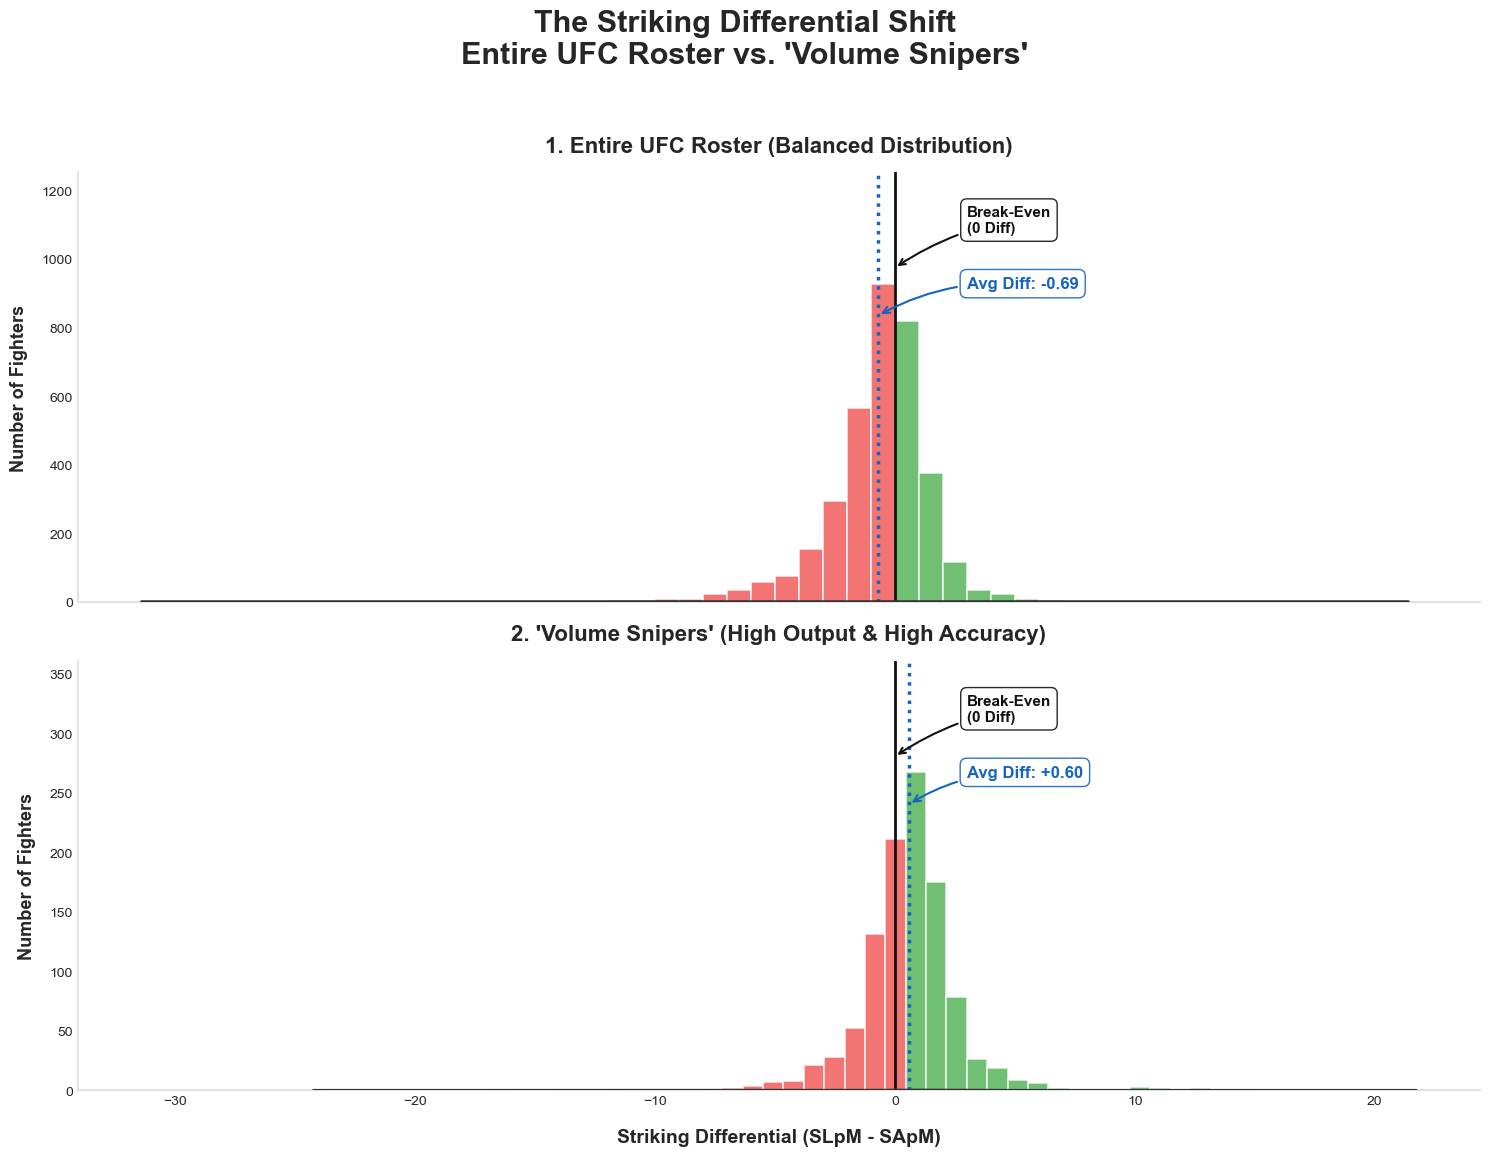

In [6]:

df['SApM'] = df['SApM'].astype(float)


df_filtered['Strike_Diff'] = df_filtered['SLpM'] - df_filtered['SApM']

median_slpm = df_filtered['SLpM'].median()
median_acc = df_filtered['Str_Acc'].median()
snipers = df_filtered[(df_filtered['SLpM'] > median_slpm) & (df_filtered['Str_Acc'] > median_acc)].copy()

plt.style.use('seaborn-v0_8-white')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
fig.suptitle("The Striking Differential Shift\nEntire UFC Roster vs. 'Volume Snipers'", fontsize=22, weight='bold', y=0.96)

def plot_colored_hist(ax, data, title, ylabel):
    counts, bins, patches = ax.hist(
        data['Strike_Diff'], 
        bins=50, 
        edgecolor='white', 
        linewidth=1.2,
        alpha=0.8, 
        zorder=2
    )
    
    max_count = max(counts)
    ax.set_ylim(0, max_count * 1.35)

    for patch, leftside in zip(patches, bins):
        if leftside >= 0:
            patch.set_facecolor('#4CAF50') 
        else:
            patch.set_facecolor('#EF5350') 

    ax.axvline(0, color='#111111', linestyle='-', linewidth=2, zorder=3)
    avg_diff = data['Strike_Diff'].mean()
    ax.axvline(avg_diff, color='#1565C0', linestyle=':', linewidth=2.5, zorder=3)
    
    sns.kdeplot(data=data, x='Strike_Diff', color='#333333', linewidth=2, ax=ax, zorder=3)
    
    
    text_x = 3.0 
    
    ax.annotate(
        "Break-Even\n(0 Diff)",
        xy=(0, max_count * 1.05), 
        xytext=(text_x, max_count * 1.2), 
        ha='left', va='center',
        fontsize=11, weight='bold', color='#111111',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#111111", alpha=0.9),
        arrowprops=dict(arrowstyle="->", color='#111111', linewidth=1.5, connectionstyle="arc3,rad=0.1"),
        zorder=5
    )

    ax.annotate(
        f"Avg Diff: {avg_diff:+.2f}",
        xy=(avg_diff, max_count * 0.9), # Point to the top of the avg line
        xytext=(text_x, max_count * 1.0), # Text box sits directly below the Break-Even box
        ha='left', va='center',
        fontsize=12, weight='bold', color='#1565C0',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#1565C0", alpha=0.9),
        arrowprops=dict(arrowstyle="->", color='#1565C0', linewidth=1.5, connectionstyle="arc3,rad=0.15"),
        zorder=5
    )
    
    ax.set_title(title, fontsize=16, weight='bold', pad=15)
    ax.set_ylabel(ylabel, fontsize=13, weight='bold', labelpad=10)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#DDDDDD')

plot_colored_hist(ax1, df_filtered, "1. Entire UFC Roster (Balanced Distribution)", "Number of Fighters")

plot_colored_hist(ax2, snipers, "2. 'Volume Snipers' (High Output & High Accuracy)", "Number of Fighters")
ax2.set_xlabel("Striking Differential (SLpM - SApM)", fontsize=14, labelpad=15, weight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()